In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

In [7]:
data22 = pd.read_csv(r"../Data/dropout_clean_2022.csv")
trimmed = pd.read_csv(r"../Data/dropout_clean_trimmed.csv")
trimmed.rename(columns={"Platform Days Logged (Total)": "Poliformat Days Logged (Total)"}, inplace=True)
data22 = data22[trimmed.columns.to_list()].drop(columns = "Entry Year")
data22.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20427 entries, 0 to 20426
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Dropout (1=Yes 0=No)            20427 non-null  int64  
 1   Performance Bucket              19262 non-null  float64
 2   Pass Rate Semester A (%)        17284 non-null  float64
 3   Pass Rate Semester B (%)        19183 non-null  float64
 4   Pass Rate Last Year (%)         14551 non-null  float64
 5   Credits Passed Normal           20427 non-null  float64
 6   Credits Passed Sem A            20427 non-null  float64
 7   Credits Passed Sem B            20427 non-null  float64
 8   Credits Enrolled Total          20427 non-null  float64
 9   Poliformat Days Logged (Total)  13891 non-null  float64
 10  Campus WiFi Days (Total)        16672 non-null  float64
dtypes: float64(10), int64(1)
memory usage: 1.7 MB


print(trimmed.columns)

from sklearn.model_selection import train_test_split

X = data22.drop(columns="Dropout (1=Yes 0=No)")
y = data22["Dropout (1=Yes 0=No)"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,          # reproducible
    stratify=y                # keeps dropout ratio equal in both splits
)

clf = tree.DecisionTreeClassifier()
clf.fit(X_train, y_train)
param_grid = {'max_leaf_nodes': range(2, clf.tree_.n_leaves + 1)}

In [8]:
clf = RandomForestClassifier()

In [9]:
clf.fit(data22.drop(columns = "Dropout (1=Yes 0=No)"), data22["Dropout (1=Yes 0=No)"]) 

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [10]:
columns = data22.columns.drop("Dropout (1=Yes 0=No)")

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = clf.predict(data22[columns])
y_test = data22["Dropout (1=Yes 0=No)"]
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     18933
           1       0.96      0.89      0.92      1494

    accuracy                           0.99     20427
   macro avg       0.98      0.94      0.96     20427
weighted avg       0.99      0.99      0.99     20427

[[18876    57]
 [  164  1330]]


FileNotFoundError: [Errno 2] No such file or directory: '../Figures/RandomForestConfusionMatrix.png'

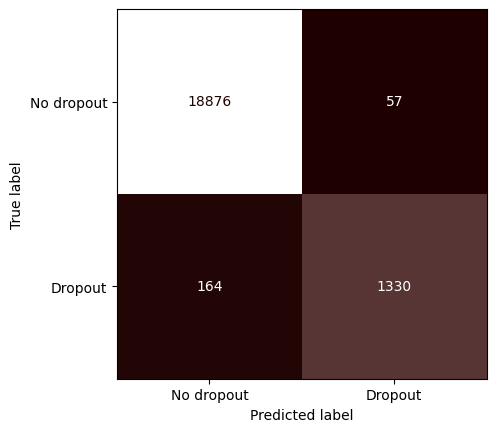

In [ ]:
from sklearn.datasets import make_classification
from sklearn.metrics import ConfusionMatrixDisplay
from matplotlib import colormaps
import os
os.makedirs("../Figures", exist_ok=True)

ConfusionMatrixDisplay.from_predictions(
    data22["Dropout (1=Yes 0=No)"], y_pred,
    labels=[0, 1],
    display_labels=["No dropout", "Dropout"],
    cmap=colormaps["pink"],
    colorbar=False
).figure_.savefig(
    os.path.join("..", "Figures", "RandomForestConfusionMatrix.png"),
    dpi=300, bbox_inches="tight"
)
